# 1. Importamos las librerías
Corremos esta celda si no tenemos las librerías instaladas.

In [1]:
# pip install requests geopandas matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
import re
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Cargamos el DataFrame

In [3]:
df_limpio = pd.read_csv('../data/processed/dataframe_limpio.tsv', sep='\t')

Revisamos si se cargó bien.

In [4]:
df_limpio.head()

,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,...,portero,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count
0,58757240,zonaprop,alquiler,750000.0,Mansilla,2936.0,0,0,0,0,...,0,300000.0,0,12500.000000,estandar,estandar,13.527830,4.110874,9.433564,5.0
1,58818211,zonaprop,alquiler,1700000.0,Cespedes,2300.0,0,0,0,1,...,0,400000.0,0,14912.280702,estandar,estandar,14.346139,4.744932,9.610007,7.0
2,58564550,zonaprop,alquiler,2500.0,Riobamba,1200.0,0,0,0,1,...,0,1150000.0,0,20.661157,estandar,estandar,7.824446,4.804021,3.075521,9.0
3,58314210,zonaprop,alquiler,1300.0,Pereyra Lucena,2500.0,0,0,0,1,...,0,384500.0,0,19.696970,estandar,estandar,7.170888,4.204693,3.029987,7.0
4,58810878,zonaprop,alquiler,3800.0,Lola Mora,400.0,0,0,0,1,...,0,507000.0,0,32.478632,premium,premium,8.243019,4.770685,3.510907,5.0


In [5]:
df_limpio.shape

(51996, 47)

Hacemos una copia para no modificar el DataFrame original.

In [6]:
df_final = df_limpio.copy()

# 3. EDA - Análisis Univariado

Estadísticos de resumen robustos para las variables numéricas clave.

In [7]:
from scipy.stats import skew, kurtosis

variables_num = ['precio', 'm2_total', 'ambientes', 'dormitorios', 'baños', 'antiguedad_años']
variables_presentes = [v for v in variables_num if v in df_final.columns]

resumen = []
for var in variables_presentes:
    serie = df_final[var].dropna()
    resumen.append({
        'variable': var,
        'n': len(serie),
        'media': serie.mean(),
        'mediana': serie.median(),
        'desvio': serie.std(),
        'asimetria': skew(serie),
        'curtosis': kurtosis(serie),
        'p5': serie.quantile(0.05),
        'p25': serie.quantile(0.25),
        'p75': serie.quantile(0.75),
        'p95': serie.quantile(0.95),
    })

pd.DataFrame(resumen).set_index('variable').round(2)

,n,media,mediana,desvio,asimetria,curtosis,p5,p25,p75,p95
variable,,,,,,,,,,
precio,51996,328892.43,155000.0,426453.37,3.91,44.23,700.0,69000.0,550000.0,1100000.0
m2_total,51996,69.81,52.0,56.92,6.88,232.81,28.0,38.0,80.0,175.0
ambientes,51996,2.33,2.0,1.19,1.67,14.17,1.0,1.0,3.0,4.0
dormitorios,51996,1.65,1.0,0.89,1.95,13.59,1.0,1.0,2.0,3.0
baños,51996,1.31,1.0,0.65,2.72,12.02,1.0,1.0,1.0,3.0
antiguedad_años,51996,25.98,20.0,19.29,0.60,0.08,0.0,10.0,40.0,60.0


El inmueble mediano tiene aproximadamente 52 m², 2 ambientes, 1 dormitorio, 1 baño y 25 años de antigüedad. La media de superficie total es mayor, cercana a 70 m², lo que sugiere la presencia de propiedades grandes que empujan el promedio hacia arriba.

In [8]:
# Prevalencia de atributos en el dataset
bool_features = ['cochera', 'aire_acond', 'luminoso', 'balcon_aterrazado',
                  'losa_central', 'seguridad', 'apto_credito']
bool_en_df = [c for c in bool_features if c in df_final.columns]

prevalencia = pd.DataFrame({
    'con_atributo': df_final[bool_en_df].sum(),
    'porcentaje (%)': (df_final[bool_en_df].mean() * 100).round(1)
}).sort_values('porcentaje (%)', ascending=False)
print("Prevalencia de atributos en el dataset:")
print(prevalencia)

Prevalencia de atributos en el dataset:
                   con_atributo  porcentaje (%)
luminoso                  31231            60.1
aire_acond                16025            30.8
cochera                   15127            29.1
seguridad                 11285            21.7
losa_central               5182            10.0
balcon_aterrazado          4842             9.3
apto_credito               3842             7.4


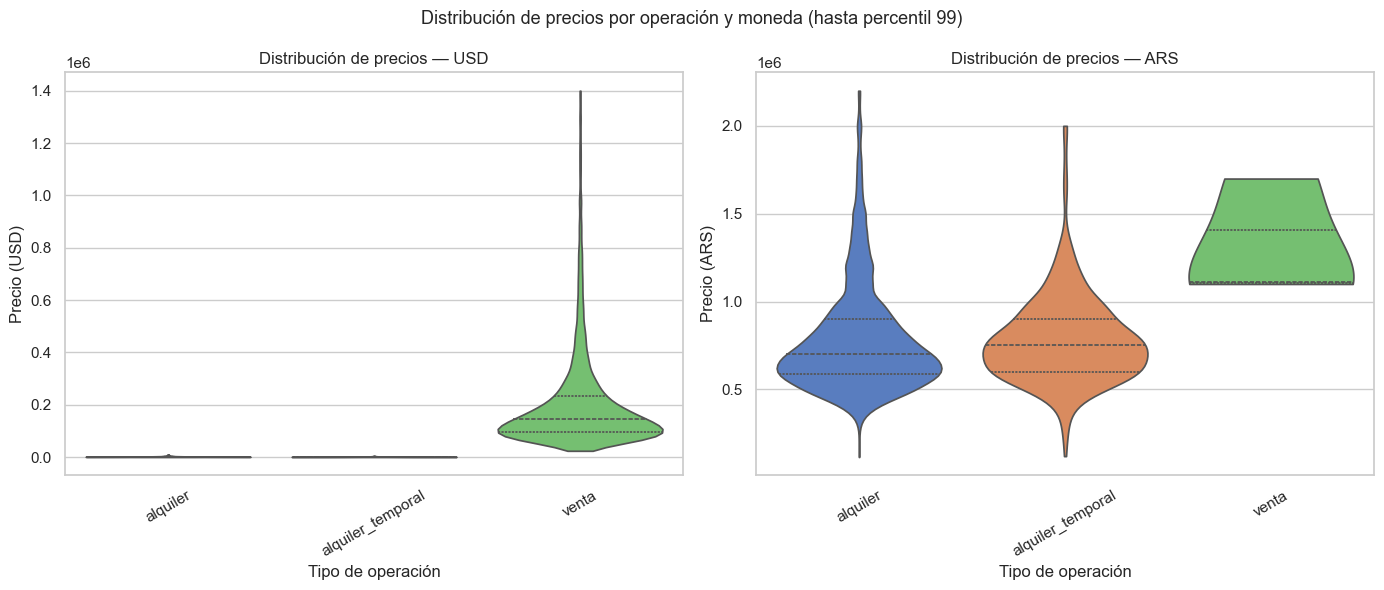

In [9]:
# Violin plot de precio por operación (separado por moneda)
# Usamos el percentil 99 para limitar el eje y y que los outliers no distorsionen la visibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, moneda in zip(axes, ['usd', 'ars']):
    subset = df_final[
        df_final['moneda'] == moneda
    ][['operacion', 'precio']].dropna()
    
    # L?mite por percentil 99 para cada segmento
    p99 = subset['precio'].quantile(0.99)
    subset = subset[subset['precio'] <= p99]
    
    sns.violinplot(data=subset, x='operacion', y='precio', ax=ax,
                   palette='muted', inner='quartile', cut=0)
    ax.set_title(f'Distribución de precios — {moneda.upper()}', fontsize=12)
    ax.set_xlabel('Tipo de operación')
    ax.set_ylabel(f'Precio ({moneda.upper()})')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Distribución de precios por operación y moneda (hasta percentil 99)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Frecuencias de variables categóricas clave
categoricas = ['operacion', 'moneda', 'barrio_oficial', 'segmento_zona', 'sitio']

for col in categoricas:
    if col not in df_final.columns:
        continue

    freq = df_final[col].value_counts().reset_index()
    freq.columns = [col, 'cantidad']
    freq['porcentaje (%)'] = (freq['cantidad'] / len(df_final) * 100).round(1)

    print(f"\n{'='*50}")
    print(f"Variable: {col} — {df_final[col].nunique()} categorías únicas")
    print(freq.to_string(index=False))


Variable: operacion — 3 categorías únicas
        operacion  cantidad  porcentaje (%)
            venta     28643            55.1
         alquiler     18220            35.0
alquiler_temporal      5133             9.9

Variable: moneda — 2 categorías únicas
moneda  cantidad  porcentaje (%)
   usd     39194            75.4
   ars     12802            24.6

Variable: barrio_oficial — 48 categorías únicas
   barrio_oficial  cantidad  porcentaje (%)
          Palermo      9459            18.2
         Recoleta      5774            11.1
         Belgrano      4737             9.1
        Caballito      3662             7.0
          Almagro      2183             4.2
    Villa Urquiza      2126             4.1
      San Nicolas      1900             3.7
            Nuñez      1881             3.6
    Puerto Madero      1765             3.4
        Balvanera      1655             3.2
     Villa Crespo      1557             3.0
           Flores      1527             2.9
        San Telmo    

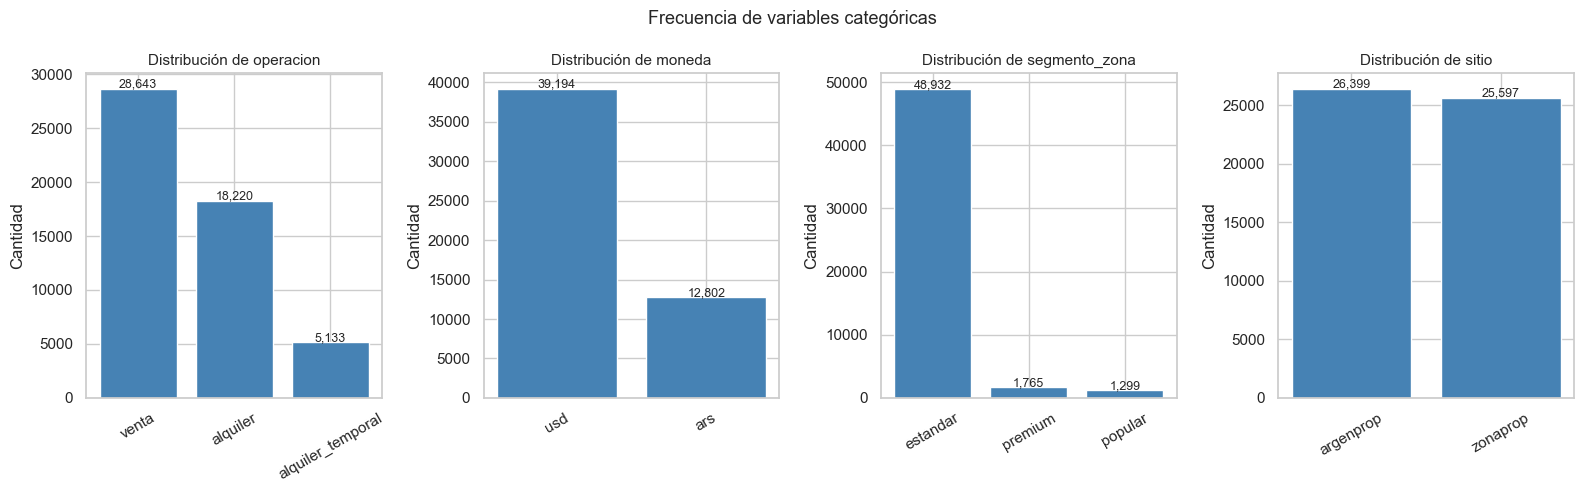

In [11]:
# Gráfico de frecuencias para las variables con pocas categorías
cols_grafico = ['operacion', 'moneda', 'segmento_zona', 'sitio']

fig, axes = plt.subplots(1, len(cols_grafico), figsize=(16, 5))

for ax, col in zip(axes, cols_grafico):
    if col not in df_final.columns:
        ax.set_visible(False)
        continue
    freq = df_final[col].value_counts()
    ax.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución de {col}', fontsize=11)
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(freq.values):
        ax.text(i, v + len(df_final)*0.003, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Frecuencia de variables categóricas', fontsize=13)
plt.tight_layout()
plt.show()

Podemos ver que hay diferencias en la frecuencia de cada categoria, habiendo en casi todas grupos claramente dominantes. La excepción es el sitio, ya que scrapeamos una cantidad similar de registros en cada uno.

# 4. EDA - Análisis Bivariado y Multivariado

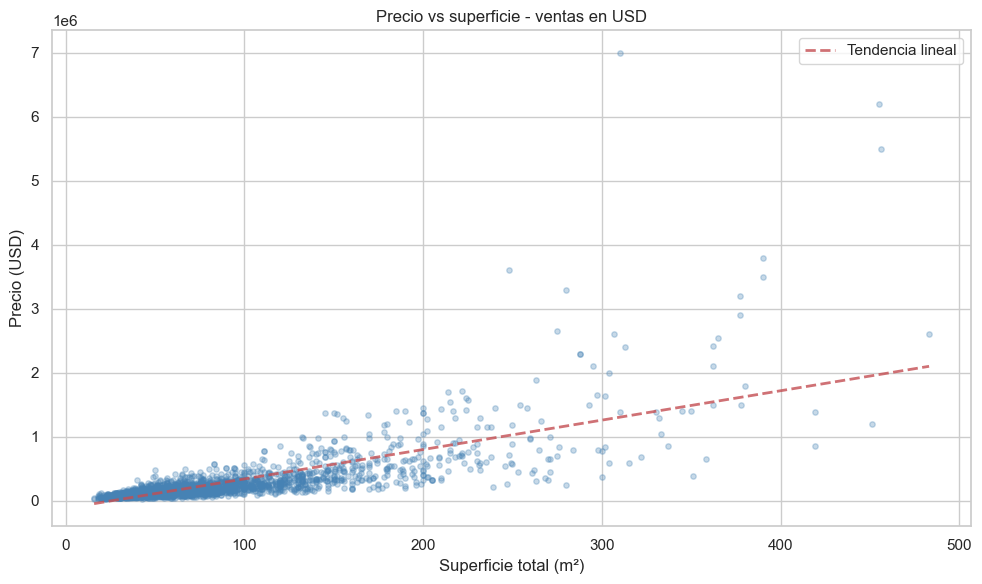

In [12]:
# Scatter de precio vs m2_total para ventas en USD
# Usamos una muestra aleatoria para evitar sobrecarga visual
subset_scatter = df_final[
    (df_final['moneda'] == 'usd') & 
    (df_final['operacion'] == 'venta') &
    df_final['precio'].notna() &
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 5) &
    (df_final['m2_total'] < 500)  # filtramos propiedades con m2 absurdo
].sample(min(3000, len(df_final)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    subset_scatter['m2_total'], 
    subset_scatter['precio'],
    alpha=0.3, s=15, color='steelblue'
)

# Línea de tendencia con regresión simple para orientación visual
z = np.polyfit(subset_scatter['m2_total'].dropna(), 
               subset_scatter['precio'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(subset_scatter['m2_total'].min(), subset_scatter['m2_total'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label='Tendencia lineal')

ax.set_xlabel('Superficie total (m²)')
ax.set_ylabel('Precio (USD)')
ax.set_title('Precio vs superficie - ventas en USD')
ax.legend()
plt.tight_layout()
plt.show()

Vemos una relación que parece lineal entre el precio y la superficie total del inmueble, más marcada en superficies menores a 100 m². En propiedades más grandes, el precio responde más a factores de lujo y ubicación que a los metros cuadrados por sí solos.

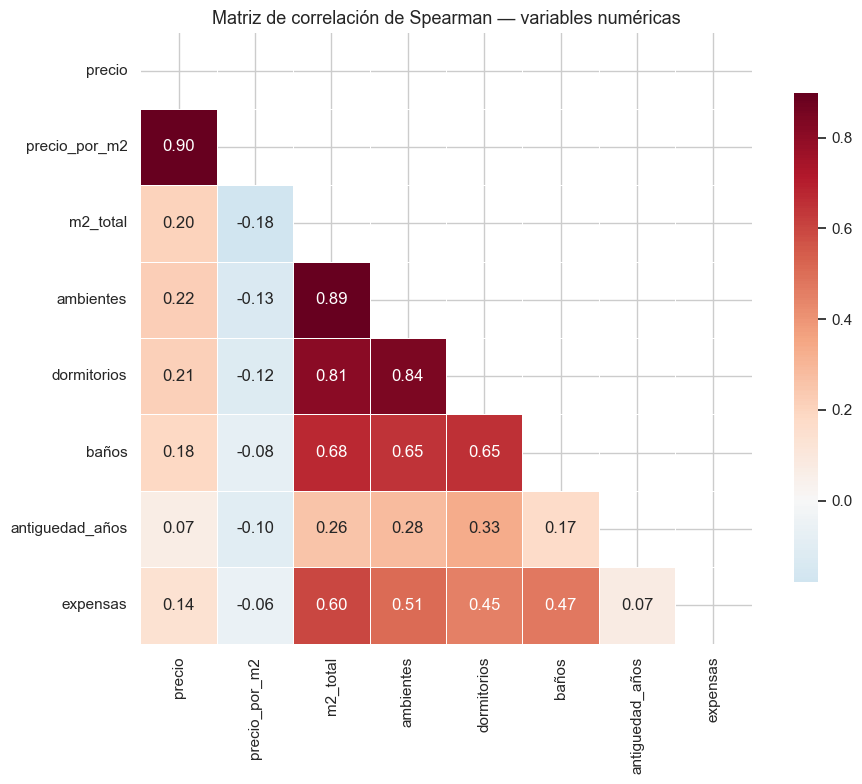

In [13]:
# Heatmap de correlación entre variables numéricas clave
# Usamos Spearman porque las distribuciones de precio no son normales
vars_correlacion = [v for v in ['precio', 'precio_por_m2', 'm2_total', 
                                 'ambientes', 'dormitorios', 'baños', 
                                 'antiguedad_años', 'expensas'] 
                    if v in df_final.columns]

corr_matrix = df_final[vars_correlacion].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación de Spearman — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

Las variables 'ambientes' y 'm2_total' presentan una correlación muy alta, al igual que 'ambientes' y 'dormitorios'. Tiene sentido: cuantos más ambientes, mayor la propiedad; y cuantos más dormitorios, más ambientes.

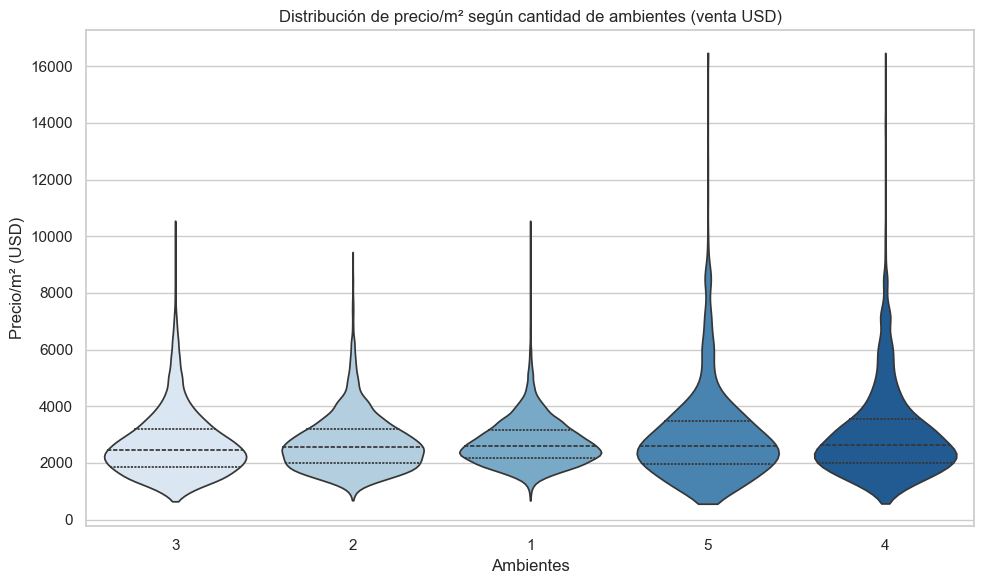

In [14]:
# Precio/m² por cantidad de ambientes (ventas USD)
# Muestra si el precio por m² cambia según el tamaño del departamento
subset_amb = df_final[
    (df_final['operacion'] == 'venta') &
    (df_final['moneda'] == 'usd') &
    df_final['ambientes'].notna() &
    df_final['precio_por_m2'].notna() &
    df_final['ambientes'].between(1, 5)  # excluimos outliers de ambientes
].copy()
subset_amb['ambientes'] = subset_amb['ambientes'].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=subset_amb, x='ambientes', y='precio_por_m2',
               palette='Blues', inner='quartile', cut=0, ax=ax)
ax.set_title('Distribución de precio/m² según cantidad de ambientes (venta USD)', fontsize=12)
ax.set_xlabel('Ambientes')
ax.set_ylabel('Precio/m² (USD)')
plt.tight_layout()
plt.show()

Vemos que las medianas tienden a mantenerse constantes, independientemente de la cantidad de ambientes que tenga el departamento. Sin embargo, los departamentos con mas ambientes (4 o 5) alcanzan valores de precio_por_m2 mucho mas altos que los demas.

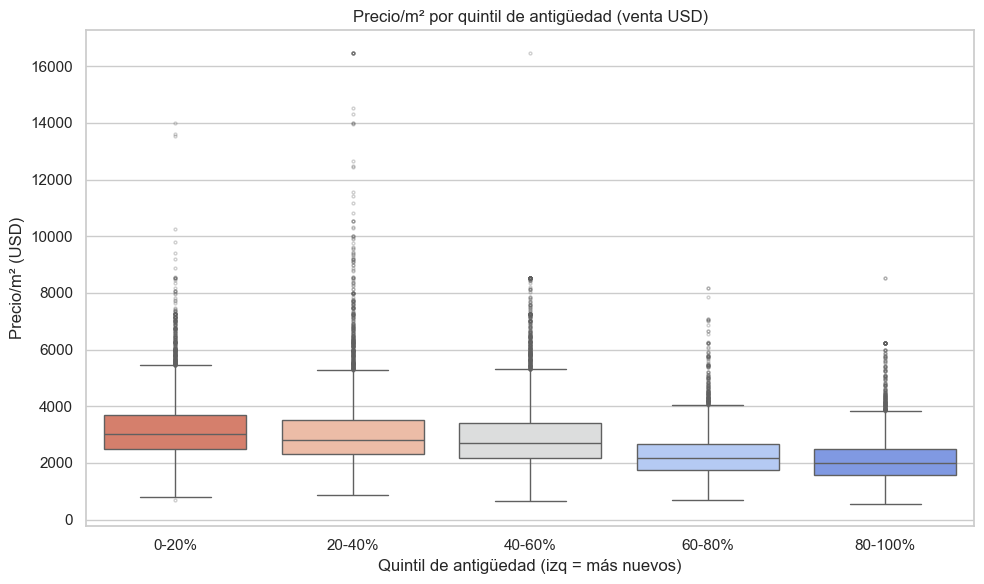

In [15]:
# Precio/m² por decil de antigüedad (ventas USD)
# Muestra si la antigüedad impacta en el precio por m²
subset_antig = df_final[
    (df_final['operacion'] == 'venta') &
    (df_final['moneda'] == 'usd') &
    df_final['antiguedad_años'].notna() &
    df_final['precio_por_m2'].notna()
].copy()

subset_antig['decil_antiguedad'] = pd.qcut(
    subset_antig['antiguedad_años'], q=5,
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=subset_antig, x='decil_antiguedad', y='precio_por_m2',
            palette='coolwarm_r', ax=ax,
            flierprops=dict(marker='.', markersize=4, alpha=0.3))
ax.set_title('Precio/m² por quintil de antigüedad (venta USD)', fontsize=12)
ax.set_xlabel('Quintil de antigüedad (izq = más nuevos)')
ax.set_ylabel('Precio/m² (USD)')
plt.tight_layout()
plt.show()

Nuevamente, no parece haber diferencias tan significativas segun la antigüedad del departamento. Lo que sí podemos ver, una leve baja en el precio_por_m2 en los departamentos más viejos. Pero esta categoría reune departamentos que tienen un componente historico que puede elevar el precio, y departamentos que pueden estar deteriorados.

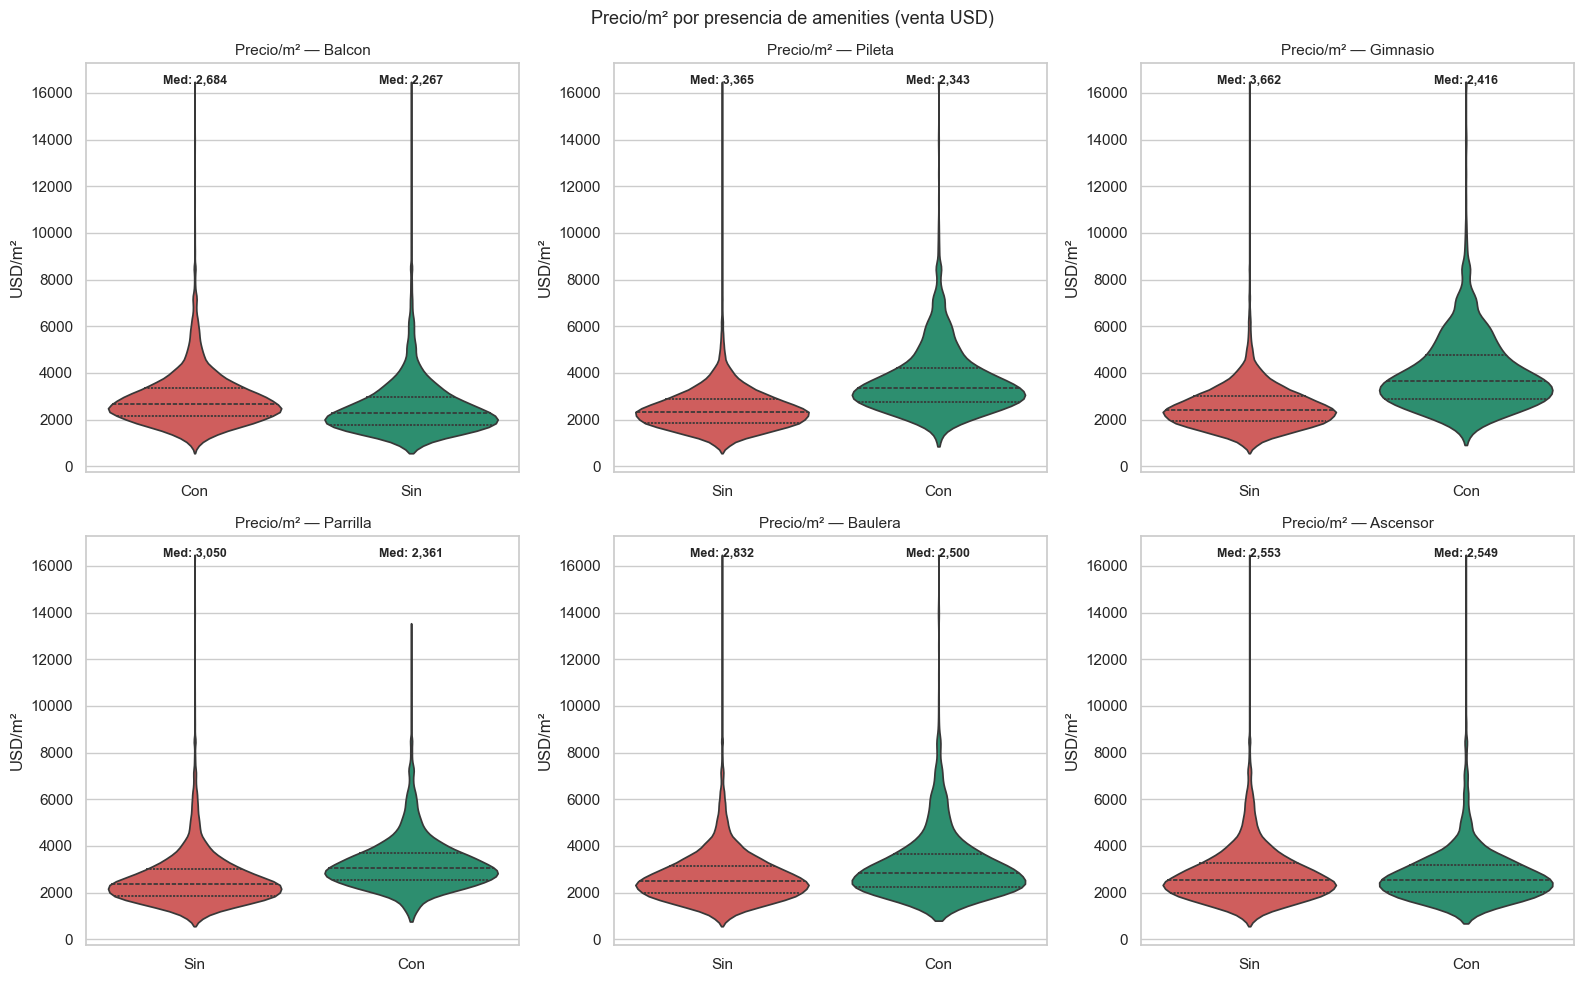

In [16]:
# Precio/m² con vs sin amenity clave: balcón, pileta, gimnasio, parrilla
# Análisis bivariado central para la Hipótesis 3
amenities_analisis = ['balcon', 'pileta', 'gimnasio', 'parrilla', 'baulera', 'ascensor']
amenities_presentes = [c for c in amenities_analisis if c in df_final.columns]

subset_venta = df_final[
    (df_final['operacion'] == 'venta') &
    (df_final['moneda'] == 'usd') &
    df_final['precio_por_m2'].notna()
].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, amenity in zip(axes, amenities_presentes):
    data_plot = subset_venta[[amenity, 'precio_por_m2']].copy()
    data_plot[amenity] = data_plot[amenity].map({1: 'Con', 0: 'Sin'})
    sns.violinplot(data=data_plot, x=amenity, y='precio_por_m2',
                   palette=['#E24B4A', '#1D9E75'], inner='quartile', cut=0, ax=ax)
    
    # Medianas sobre el gráfico
    for val, label in [(1, 'Con'), (0, 'Sin')]:
        med = subset_venta[subset_venta[amenity] == val]['precio_por_m2'].median()
        ax.text([0, 1][val == 0], ax.get_ylim()[1] * 0.95,
                f'Med: {med:,.0f}', ha='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f'Precio/m² — {amenity.capitalize()}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('USD/m²')

# Ocultamos el subplot sobrante si hay menos de 6 amenities
for i in range(len(amenities_presentes), len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Precio/m² por presencia de amenities (venta USD)', fontsize=13)
plt.tight_layout()
plt.show()

En este grafico, vemos que departamentos con amenities, tienen un nivel de precios algo superior a los que no tienen. Esta diferencia se ve especialmente en las variables pileta y gimnasio. Esto tiene sentido que le sume valor a una propiedad.

In [17]:
# Tabla de contingencia: tipo de operación × segmento de zona
# Muestra si la distribución de operaciones varía según la zona
tabla_op_zona = pd.crosstab(
    df_final['operacion'],
    df_final['segmento_zona'],
    margins=True,
    margins_name='Total'
)
tabla_op_zona_pct = pd.crosstab(
    df_final['operacion'],
    df_final['segmento_zona'],
    normalize='index'
).round(3) * 100

print("=== Tabla de contingencia: operación × segmento de zona ===")
print("\nCantidades absolutas:")
print(tabla_op_zona)
print("\nDistribución porcentual por operación (%):")
print(tabla_op_zona_pct.round(1))

=== Tabla de contingencia: operación × segmento de zona ===

Cantidades absolutas:
segmento_zona      estandar  popular  premium  Total
operacion                                           
alquiler              16950      330      940  18220
alquiler_temporal      4876        7      250   5133
venta                 27106      962      575  28643
Total                 48932     1299     1765  51996

Distribución porcentual por operación (%):
segmento_zona      estandar  popular  premium
operacion                                    
alquiler               93.0      1.8      5.2
alquiler_temporal      95.0      0.1      4.9
venta                  94.6      3.4      2.0


Por la cantidad de datos que teniamos al construir la variable, podemos ver una clara diferencia en los porcentajes.

# 5. Análisis Geográfico

Ahora, analizaremos en particular una de las dimensiones que nos parece más importante: el barrio donde se ubica el departamento.

In [18]:
import requests
import geopandas as gpd

# Descargamos el GeoJSON oficial de barrios de la Ciudad de Buenos Aires desde datos abiertos
url_geojson = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
geojson_barrios = requests.get(url_geojson).json()

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}

df_filtrado = df_final[df_final["barrio_oficial"].isin(nombres_geojson)]
conteo = df_filtrado.groupby("barrio_oficial").size().reset_index(name="cantidad")

nombres_df = set(conteo["barrio_oficial"])
print("Barrios sin coincidencia en el GeoJSON:", nombres_df - nombres_geojson)


Barrios sin coincidencia en el GeoJSON: set()


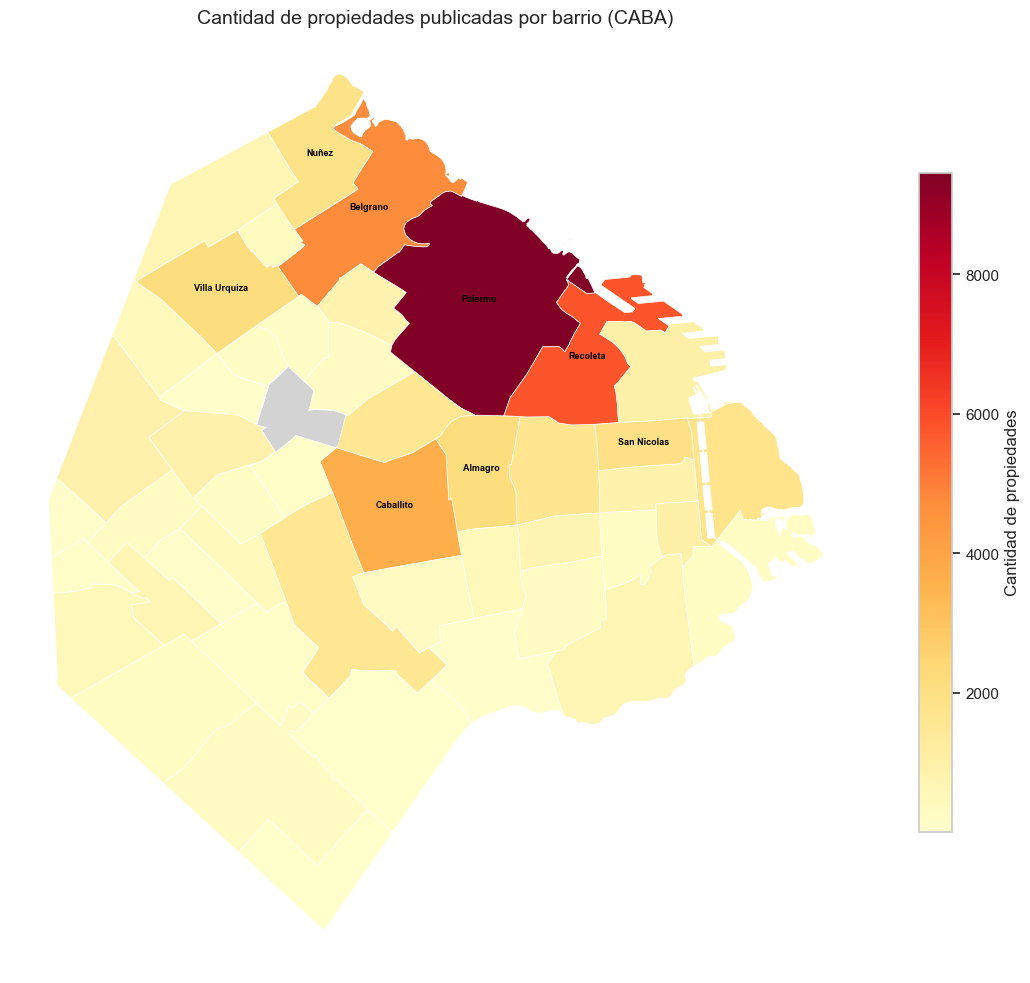

In [19]:
# Construimos el GeoDataFrame de barrios y lo mergeamos con el conteo de propiedades
gdf = gpd.GeoDataFrame.from_features(geojson_barrios["features"])
gdf = gdf.rename(columns={"nombre": "barrio_oficial"})
gdf = gdf.set_crs("EPSG:4326")

gdf_conteo = gdf.merge(conteo, on="barrio_oficial", how="left")

# --- Mapa: cantidad de propiedades por barrio ---
fig, ax = plt.subplots(figsize=(12, 10))

gdf_conteo.plot(
    column="cantidad",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Cantidad de propiedades", "shrink": 0.7},
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
    ax=ax,
)

# Anotamos los top-8 barrios por cantidad
top_barrios = gdf_conteo.nlargest(8, "cantidad")
for _, row in top_barrios.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["barrio_oficial"],
        xy=(centroide.x, centroide.y),
        ha="center",
        fontsize=6.5,
        color="black",
        fontweight="bold",
    )

ax.set_title("Cantidad de propiedades publicadas por barrio (CABA)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


En el mapa vemos que Palermo, Belgrano, Recoleta y Caballito son los barrios con mayor representación en el dataset. Esto corresponde con la popularidad reciente general de estos barrios. 

A continuación presentamos mapas del precio mediano por barrio, separados por tipo de operación y moneda. Usamos la columna 'precio' (ya limpia) del DataFrame principal. Para venta calculamos también el precio mediano por m².

In [20]:
def graficar_mapa_precio(gdf_base, df_source, filtro_operacion, filtro_moneda,
                          columna_precio, titulo, etiqueta_leyenda,
                          cmap="Blues", top_n=8, fmt_precio="{:,.0f}"):
    """
    Genera un mapa coroplético de precio mediano por barrio usando geopandas + matplotlib.

    Parámetros
    ----------
    gdf_base           : GeoDataFrame con la geometría de los barrios (columna 'barrio_oficial')
    df_source          : DataFrame con columnas barrio_oficial, operacion, moneda y columna_precio
    filtro_operacion   : str, valor de la columna 'operacion' a filtrar
    filtro_moneda      : str, valor de la columna 'moneda' a filtrar
    columna_precio     : str, columna numérica a agregar con la mediana
    titulo             : str, título del mapa
    etiqueta_leyenda   : str, etiqueta de la barra de colores
    cmap               : str, colormap de matplotlib
    top_n              : int, cantidad de barrios a anotar
    fmt_precio         : str, formato para el texto de anotación
    """
    # Filtrado y cálculo de mediana por barrio
    mask = (
        (df_source["operacion"] == filtro_operacion)
        & (df_source["moneda"] == filtro_moneda)
        & df_source[columna_precio].notna()
        & (df_source[columna_precio] > 0)
        & df_source["barrio_oficial"].notna()
    )
    estadisticas = (
        df_source[mask]
        .groupby("barrio_oficial")[columna_precio]
        .median()
        .reset_index()
        .rename(columns={columna_precio: "precio_mediano"})
    )

    gdf_merge = gdf_base.merge(estadisticas, on="barrio_oficial", how="left")

    fig, ax = plt.subplots(figsize=(12, 10))

    gdf_merge.plot(
        column="precio_mediano",
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=True,
        legend_kwds={"label": etiqueta_leyenda, "shrink": 0.7},
        missing_kwds={"color": "lightgray", "label": "Sin datos"},
        ax=ax,
    )

    # Anotamos los top-N barrios con mayor precio mediano
    top = gdf_merge.dropna(subset=["precio_mediano"]).nlargest(top_n, "precio_mediano")
    for _, row in top.iterrows():
        centroide = row.geometry.centroid
        ax.annotate(
            row["barrio_oficial"],
            xy=(centroide.x, centroide.y),
            ha="center",
            fontsize=6,
            color="black",
            fontweight="bold",
        )

    ax.set_title(titulo, fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [21]:
# df_geo contiene solo los registros con barrio_oficial válido para el análisis geoespacial
# m2_total y precio_por_m2 requieren que el parseo de detalles y descripción ya esté ejecutado
df_geo = df_filtrado.copy()

if "m2_total" in df_final.columns:
    df_geo["m2_total"] = df_final.loc[df_geo.index, "m2_total"]
    mask_m2 = df_geo["m2_total"].notna() & (df_geo["m2_total"] > 5) & df_geo["precio"].notna() & (df_geo["precio"] > 0)
    df_geo.loc[mask_m2, "precio_por_m2"] = df_geo.loc[mask_m2, "precio"] / df_geo.loc[mask_m2, "m2_total"]
    print(f"Registros con precio_por_m2 calculado: {mask_m2.sum():,}")
else:
    print("m2_total aún no disponible (ejecutar sección de parseo de detalles primero).")

print(f"Registros en df_geo: {len(df_geo):,}")
print(df_geo[["operacion", "moneda"]].value_counts())


Registros con precio_por_m2 calculado: 51,777
Registros en df_geo: 51,777
operacion          moneda
venta              usd       28506
alquiler           ars       12258
                   usd        5877
alquiler_temporal  usd        4674
                   ars         458
venta              ars           4
Name: count, dtype: int64


### Precio mediano de venta (USD) por barrio

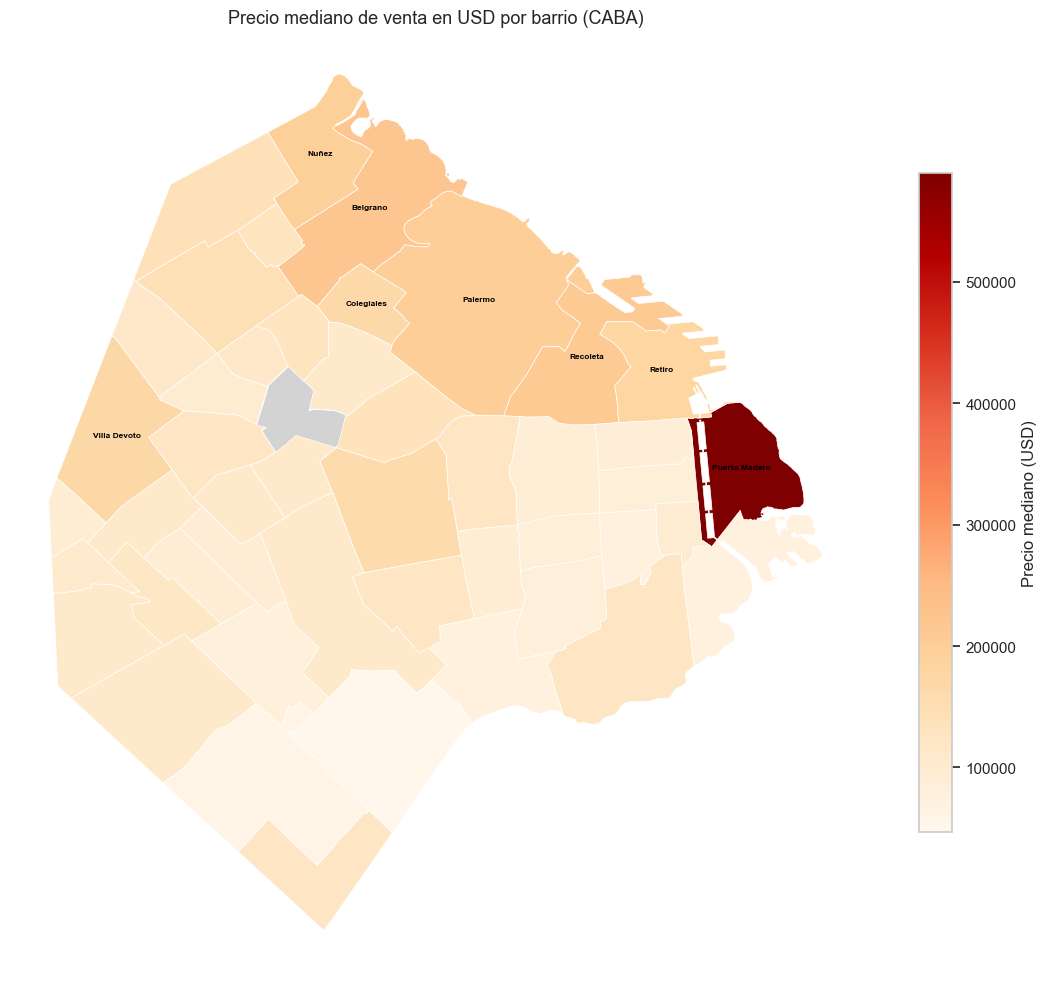

In [22]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="venta",
    filtro_moneda="usd",
    columna_precio="precio",
    titulo="Precio mediano de venta en USD por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (USD)",
    cmap="OrRd",
    top_n=8,
)


Esto corresponde con suposiciones de conocimiento general: Puerto Madero es un barrio de lujo cuyos precios tienen una diferencia importante con respecto a los demás barrios. Barrios muy demandados (Recoleta, Palermo, Belgrano, Núñez) le siguen. 

### Precio mediano de alquiler (ARS) por barrio

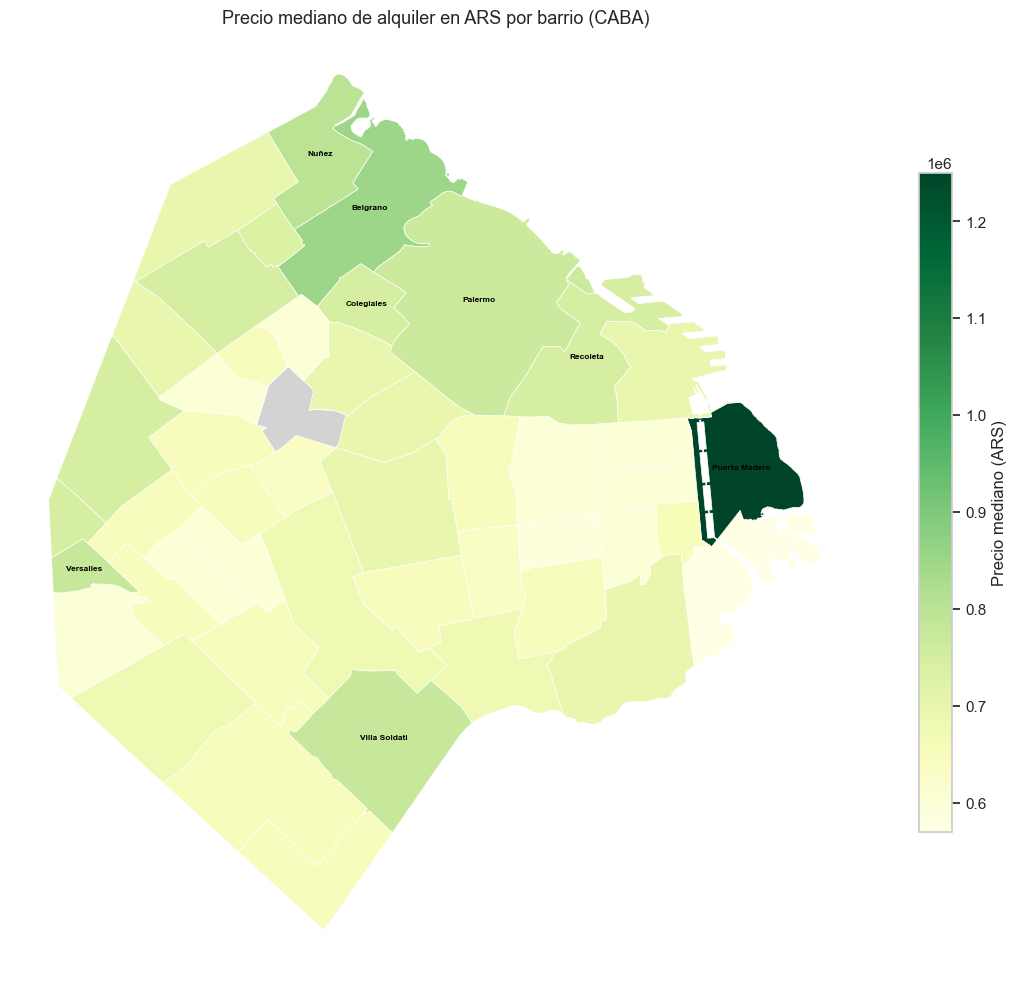

In [23]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="alquiler",
    filtro_moneda="ars",
    columna_precio="precio",
    titulo="Precio mediano de alquiler en ARS por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (ARS)",
    cmap="YlGn",
    top_n=8,
)


### Precio mediano por m² en venta (USD) por barrio

Este mapa muestra el precio mediano por metro cuadrado para propiedades en venta con precio en dólares. La columna 'm2_total' proviene del parseo de la columna 'detalles' (superficie total o cubierta). Solo incluimos propiedades con 'm2_total > 5 m²'.

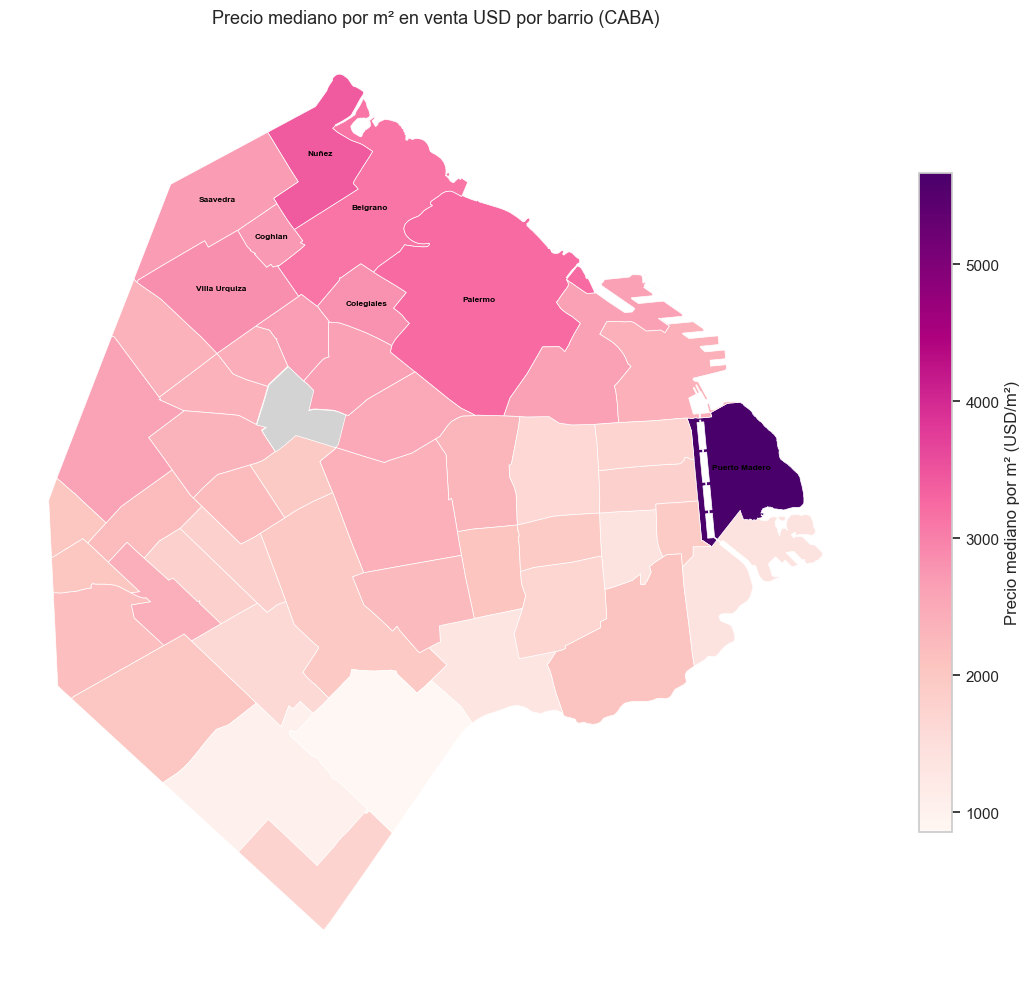

In [24]:
if "precio_por_m2" in df_geo.columns:
    graficar_mapa_precio(
        gdf_base=gdf,
        df_source=df_geo,
        filtro_operacion="venta",
        filtro_moneda="usd",
        columna_precio="precio_por_m2",
        titulo="Precio mediano por m² en venta USD por barrio (CABA)",
        etiqueta_leyenda="Precio mediano por m² (USD/m²)",
        cmap="RdPu",
        top_n=8,
    )
else:
    print("No se pudo generar el mapa: la columna 'precio_por_m2' no está disponible.")
    print("Asegurate de ejecutar la celda de parseo de 'detalles' antes de esta.")


En todos los mercados, barrios como Puerto Madero, Palermo, Recoleta y Belgrano mantienen los precios más altos. En este último gráfico destaca Núñez, el cual presenta una popularidad creciente recientemente. Cada vez hay más proyectos en este barrio (incluyendo el campus del ITBA mimso)ñ

In [25]:
tabla_barrio_operacion = (
    df_final.groupby(["barrio_oficial", "operacion"])
      .size()
      .unstack(fill_value=0)
)

tabla_barrio_operacion["Total_barrio"] = tabla_barrio_operacion.sum(axis=1)
tabla_barrio_operacion.loc["Total_operacion"] = tabla_barrio_operacion.sum(axis=0)

tabla_barrio_operacion

operacion,alquiler,alquiler_temporal,venta,Total_barrio
barrio_oficial,,,,
Agronomia,26,1,43,70
Almagro,709,211,1263,2183
Balvanera,566,83,1006,1655
Barracas,187,11,437,635
Belgrano,1508,416,2813,4737
Boedo,143,8,299,450
Caballito,1287,154,2221,3662
Chacarita,90,27,175,292
Coghlan,75,15,279,369


El barrio con menor cantidad de propiedades es Villa Riachuelo, con 5 registros. La operación con menor volumen es 'alquiler_temporal'. Esperamos que las conclusiones más robustas sean sobre los barrios con mayor presencia en el dataset, aunque 'alquiler_temporal', con más de 8.000 filas, permite obtener resultados sólidos para los tres tipos de operación.

## Segmentación territorial del mercado

Todo este análisis evidencia una fuerte heterogeneidad territorial dentro del mercado inmobiliario.

Determinados barrios concentran valores significativamente superiores, tanto en precio absoluto como en precio por metro cuadrado, lo que refleja dinámicas diferenciadas de demanda, accesibilidad, amenities urbanas y perfil socioeconómico.

Esta segmentación territorial refuerza la necesidad de analizar el mercado desde una lógica de micro-zonas y no únicamente a nivel agregado.